# Тестування алгоритму на синтетичних даних
**Етап валідації методології**

###  Мета
Перевірити коректність роботи алгоритму **FloodModel (BFS)** в контрольованих умовах перед запуском на реальній карті Одеси.

### Проблема
Простий метод "порогового відсікання" (`height < water_level`) помилково затоплює ізольовані низини (яри, кар'єри), які не мають сполучення з морем.

### Рішення
Використання алгоритму пошуку в ширину (BFS), який імітує фізичне розливання води від джерела (моря) і затоплює лише ті ділянки, до яких вода може дістатися.

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]   # flood_climate_coursework
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


### 1. Генерація синтетичного рельєфу 
Створюємо штучну карту висот розміром 32x32 пікселі, яка містить ключові елементи для перевірки алгоритму:
1.  **Море:** Глибока зона в правому нижньому куті (-15м).
2.  **Суша:** Височина (2-10м).
3.  **Берегова лінія:** Плавний перехід.
4.  **"Пастки" (Internal Depressions):** Штучно створені ями всередині суші (-6м), які оточені високими берегами.

**Очікування:** Наївний алгоритм має затопити ці ями, а BFS-алгоритм — залишити їх сухими.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# seed = 42
def generate_random_dem(seed=None):
    rng = np.random.default_rng(seed)

    # базова суша: 2–10 м
    dem = rng.uniform(2.0, 10.0, size=(32, 32))

    # море внизу справа
    dem[24:32, 24:32] = rng.uniform(-15.0, -5.0, size=(8, 8))

    # гарантовано: стартова клітинка — море
    dem[31, 31] = -10.0

    # прибережна зона
    dem[22:24, 24:32] = rng.uniform(0.0, 1.0, size=(2, 8))
    dem[24:32, 22:24] = rng.uniform(0.0, 1.0, size=(8, 2))

    # випадкові внутрішні депресії (псевдо-лимани)
    for _ in range(3):
        i = rng.integers(2, 20)
        j = rng.integers(2, 20)
        h = rng.uniform(-6.0, -2.0)
        dem[i:i+3, j:j+3] = h

    return dem




In [3]:
dem = generate_random_dem()

print("Shape:", dem.shape)
print("Bottom-right value (sea):", dem[-1, -1])
print("Min / Max:", dem.min(), dem.max())


Shape: (32, 32)
Bottom-right value (sea): -10.0
Min / Max: -14.685795629991771 9.994953456132972


### 2. Реалізація тестових функцій
Для наочності порівняння реалізуємо два підходи "з нуля" прямо в ноутбуці:
* `naive_flood`: Проста перевірка умови `h < level`.
* `connected_flood`: Спрощена версія BFS (черга, відвідування сусідів), що починає заливку з точки моря.

In [4]:
def naive_flood(dem, water_level):
    return dem < water_level
def connected_flood(dem, water_level):
    rows, cols = dem.shape
    flooded = np.zeros_like(dem, dtype=bool)
    visited = np.zeros_like(dem, dtype=bool)

    q = deque()
    si, sj = rows - 1, cols - 1  # умовне відкрите море

    q.append((si, sj))
    visited[si, sj] = True

    if dem[si, sj] < water_level:
        flooded[si, sj] = True

    neighbors = [(-1,0),(1,0),(0,-1),(0,1)]

    while q:
        i, j = q.popleft()
        for di, dj in neighbors:
            ni, nj = i + di, j + dj
            if 0 <= ni < rows and 0 <= nj < cols:
                if visited[ni, nj]:
                    continue
                visited[ni, nj] = True

                if dem[ni, nj] < water_level:
                    flooded[ni, nj] = True
                    q.append((ni, nj))

    return flooded


### 3. Візуальне порівняння та Висновки
Запускаємо симуляцію для різних рівнів підняття води: **+.. м**.

**На графіках нижче:**
* **Верхній ряд (Наївний метод):** Помилково зафарбовує ізольовані ями всередині "материка", навіть якщо вода туди фізично не може потрапити.
* **Нижній ряд (Зв'язність моря / BFS):** Коректно обтікає перешкоди. Вода потрапляє в ями тільки тоді, коли рівень моря перевищує висоту бар'єра ("переливається" через край).

**Висновок:** Алгоритм BFS працює коректно і готовий до використання на реальних даних.

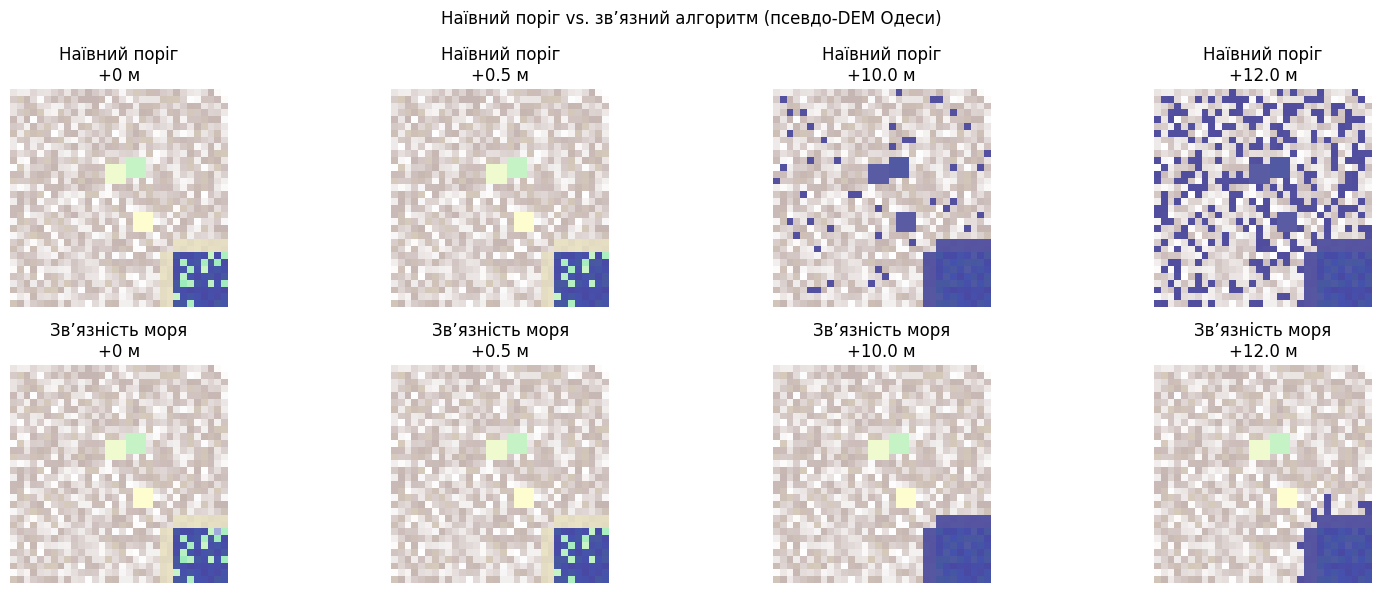

In [5]:
from src.model import FloodModel

scenarios = [0,0.5,10.0, 12.0]

model = FloodModel(dem)

sea_bias = model.calibrate_sea_level()

fig, axes = plt.subplots(2, len(scenarios), figsize=(16, 6))

for j, H in enumerate(scenarios):
    level = sea_bias + H

    naive_mask = model.simple_threshold(level)
    connected_mask = model.calculate_flood(level)

    for i, (mask, title) in enumerate([
        (naive_mask, "Наївний поріг"),
        (connected_mask, "Зв’язність моря")
    ]):
        ax = axes[i, j]

        ax.imshow(dem, cmap="terrain", alpha=0.45)

        flooded = np.ma.masked_where(~mask, mask)
        ax.imshow(flooded, cmap="terrain", alpha=0.8)

        ax.set_title(f"{title}\n+{H} м")
        ax.axis("off")

plt.suptitle("Наївний поріг vs. зв’язний алгоритм (псевдо-DEM Одеси)")
plt.tight_layout()
plt.show()
